In [11]:
# ==========================================================
# 04_shap_stability_analysis_MAR_randomForest.py
# Full Dataset MAR + KNN + SHAP Stability
# Random Forest
# ==========================================================

import pandas as pd
import numpy as np
import os
import shap
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

from sklearn.model_selection import train_test_split
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier

# ----------------------------------------------------------
# 1. Load Dataset
# ----------------------------------------------------------
file_path = "../dataset/clean_dengue_dataset.csv"
df = pd.read_csv(file_path)

# ----------------------------------------------------------
# 2. Load Baseline SHAP Importance
# ----------------------------------------------------------
baseline_path = "outputs/baseline_randomForest_shap_importance.csv"
baseline_df = pd.read_csv(baseline_path)

# ----------------------------------------------------------
# 3. Separate Features / Target
# ----------------------------------------------------------
target_column = "dengue_label"

X = df.drop(columns=[target_column])
y = df[target_column]

feature_names = X.columns.tolist()

# ----------------------------------------------------------
# 4. Train-Test Split
# ----------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

# ----------------------------------------------------------
# 5. Create Output Folders
# ----------------------------------------------------------
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/plots", exist_ok=True)

In [12]:
# ----------------------------------------------------------
# 6. Full Dataset MAR Function
# ----------------------------------------------------------
def inject_mar_missingness(df_input, level, random_state=42):

    np.random.seed(random_state)

    df_missing = df_input.copy()

    n = len(df_missing)

    for i in range(n):

        if pd.notnull(df_missing.loc[i, "age"]):
            if df_missing.loc[i, "age"] > 50:
                if np.random.rand() < level:
                    df_missing.loc[i, "hemoglobin_g_dl"] = np.nan

        if pd.notnull(df_missing.loc[i, "platelet_count"]):
            if df_missing.loc[i, "platelet_count"] < 80000:
                if np.random.rand() < level:
                    df_missing.loc[i, "wbc_count"] = np.nan

        if df_missing.loc[i, "gender"] == 1:
            if np.random.rand() < level:
                df_missing.loc[i, "rbc_count"] = np.nan

        if df_missing.loc[i, "gender"] == 2:
            if np.random.rand() < level:
                df_missing.loc[i, "age"] = np.nan

        if pd.notnull(df_missing.loc[i, "wbc_count"]):
            if df_missing.loc[i, "wbc_count"] < 3000:
                if np.random.rand() < level:
                    df_missing.loc[i, "differential_count"] = np.nan

        if pd.notnull(df_missing.loc[i, "hemoglobin_g_dl"]):
            if df_missing.loc[i, "hemoglobin_g_dl"] < 12:
                if np.random.rand() < level:
                    df_missing.loc[i, "platelet_count"] = np.nan

        if pd.notnull(df_missing.loc[i, "platelet_distribution_width"]):
            if df_missing.loc[i, "platelet_distribution_width"] > 16:
                if np.random.rand() < level:
                    df_missing.loc[i, "rbc_count"] = np.nan

        if pd.notnull(df_missing.loc[i, "age"]):
            if df_missing.loc[i, "age"] < 18:
                if np.random.rand() < level:
                    df_missing.loc[i, "platelet_distribution_width"] = np.nan

    return df_missing

# ----------------------------------------------------------
# 7. Compute SHAP Importance Function
# ----------------------------------------------------------
def compute_shap_importance(model, X_test_imp):

    explainer = shap.TreeExplainer(model)

    raw_shap = explainer.shap_values(X_test_imp)

    if isinstance(raw_shap, list):
        shap_values = raw_shap[1]

    elif len(np.array(raw_shap).shape) == 3:
        shap_values = raw_shap[:, :, 1]

    else:
        shap_values = raw_shap

    importance = np.abs(shap_values).mean(axis=0)

    result = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })

    return result

# ----------------------------------------------------------
# 8. Baseline Ranking
# ----------------------------------------------------------
baseline_df["Rank_Baseline"] = baseline_df["Importance"].rank(
    ascending=False,
    method="average"
)



In [13]:
# ----------------------------------------------------------
# 9. MAR Levels
# ----------------------------------------------------------
mar_levels = [0.05, 0.10, 0.20, 0.30, 0.4, 0.5, 0.6, 0.7, 0.8]

stability_results = []
all_importance = []

# ----------------------------------------------------------
# 10. Loop Through Levels
# ----------------------------------------------------------
for level in mar_levels:

    print("=" * 60)
    print(f"Processing MAR Level: {int(level*100)}%")
    print("=" * 60)

    # --------------------------------------
    # Inject MAR Missingness
    # --------------------------------------
    X_train_mar = inject_mar_missingness(X_train, level)

    missing_count = X_train_mar.isnull().sum().sum()

    # --------------------------------------
    # KNN Imputation
    # --------------------------------------
    imputer = KNNImputer(n_neighbors=5)

    X_train_imp = imputer.fit_transform(X_train_mar)
    X_test_imp = imputer.transform(X_test)

    # --------------------------------------
    # Train Random Forest
    # --------------------------------------
    model = RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_imp, y_train)

    # --------------------------------------
    # SHAP Importance
    # --------------------------------------
    current_df = compute_shap_importance(model, X_test_imp)

    current_df["Rank_MAR"] = current_df["Importance"].rank(
        ascending=False,
        method="average"
    )

    current_df["MAR_Level"] = int(level * 100)

    all_importance.append(current_df)


    # --------------------------------------
    # Display Feature Ranking in Console
    # --------------------------------------
    ranking_display = current_df[
        ["Feature", "Importance", "Rank_MAR"]
    ].sort_values("Rank_MAR")

    print(f"\nFeature Ranking at MAR {int(level*100)}%:")
    print(ranking_display.to_string(index=False))

    all_importance.append(current_df)
    
    # --------------------------------------
    # Merge Baseline vs Current
    # --------------------------------------
    merged = baseline_df.merge(
        current_df,
        on="Feature",
        suffixes=("_Baseline", "_MAR")
    )

    # --------------------------------------
    # Rank-based Spearman Correlation
    # --------------------------------------
    corr, _ = spearmanr(
        merged["Rank_Baseline"],
        merged["Rank_MAR"]
    )

    stability_results.append({
        "MAR_Level": int(level * 100),
        "Missing_Values": missing_count,
        "Spearman_Correlation": corr
    })

    print(f"Missing Values : {missing_count}")
    print(f"SHAP Stability : {corr:.4f}")

# ----------------------------------------------------------
# 11. Save CSV Results
# ----------------------------------------------------------
stability_df = pd.DataFrame(stability_results)

stability_df.to_csv(
    "outputs/randomForest_MAR_shap_stability.csv",
    index=False
)

importance_df = pd.concat(all_importance)

importance_df.to_csv(
    "outputs/randomForest_MAR_feature_importance.csv",
    index=False
)


Processing MAR Level: 5%

Feature Ranking at MAR 5%:
                    Feature  Importance  Rank_MAR
                  wbc_count    0.182444       1.0
             platelet_count    0.141354       2.0
platelet_distribution_width    0.031670       3.0
            hemoglobin_g_dl    0.025464       4.0
                        age    0.023531       5.0
                     gender    0.009964       6.0
                  rbc_count    0.004217       7.0
         differential_count    0.003863       8.0
Missing Values : 146
SHAP Stability : 1.0000
Processing MAR Level: 10%

Feature Ranking at MAR 10%:
                    Feature  Importance  Rank_MAR
                  wbc_count    0.191117       1.0
             platelet_count    0.136091       2.0
platelet_distribution_width    0.034494       3.0
            hemoglobin_g_dl    0.026394       4.0
                        age    0.020949       5.0
                     gender    0.010381       6.0
                  rbc_count    0.006239       7

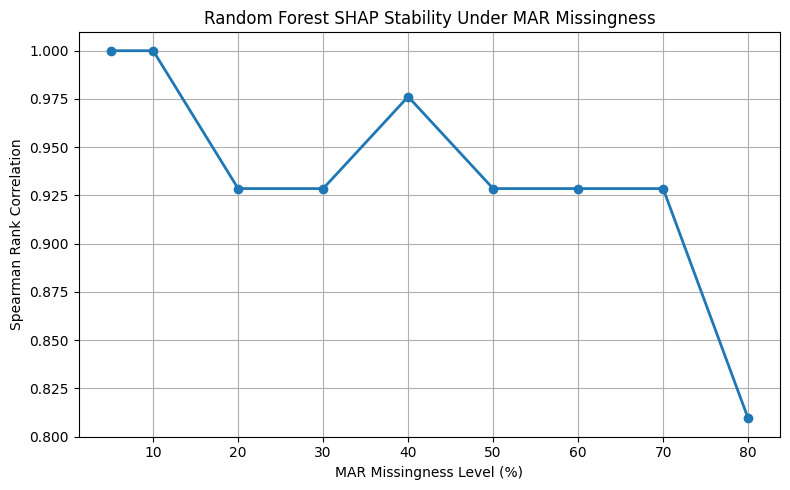

Plot saved successfully.

PROCESS COMPLETED SUCCESSFULLY


In [14]:

# ----------------------------------------------------------
# 12. Plot Graph
# ----------------------------------------------------------
plt.figure(figsize=(8,5))

plt.plot(
    stability_df["MAR_Level"],
    stability_df["Spearman_Correlation"],
    marker="o",
    linewidth=2
)

plt.title("Random Forest SHAP Stability Under MAR Missingness")
plt.xlabel("MAR Missingness Level (%)")
plt.ylabel("Spearman Rank Correlation")
plt.grid(True)

plt.tight_layout()
plt.show()
# plt.savefig(
#     "outputs/plots/randomForest_MAR_shap_stability.png",
#     dpi=300
# )

plt.close()

print("Plot saved successfully.")

print("\nPROCESS COMPLETED SUCCESSFULLY")